<a href="https://colab.research.google.com/github/eshan14git/football-qa-nlp/blob/disath-dev/notebooks/Disa_Football_NLQA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Markdown Cell
Football Natural Language Question Answering (NLQA) System

Machine Learning Model - Logistic Regression

Deep Learning Model - Convolutional Neural Network (CNN)

## Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Text processing
import re
import string

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Machine Learning Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Download NLP Resources

In [2]:
# Download required NLTK resources

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Mount Google Drive

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Load the Dataset

In [4]:
# Dataset path

file_path = "/content/drive/MyDrive/NLP/data/results.csv"

football_df = pd.read_csv(file_path)

football_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## Dataset Overview

In [5]:
# Display the first five rows

football_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## Dataset Information

In [6]:
# Display dataset information

football_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49477 non-null  object 
 1   home_team   49477 non-null  object 
 2   away_team   49477 non-null  object 
 3   home_score  49433 non-null  float64
 4   away_score  49433 non-null  float64
 5   tournament  49477 non-null  object 
 6   city        49477 non-null  object 
 7   country     49477 non-null  object 
 8   neutral     49477 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


## Dataset Description

In [7]:
# Display statistical summary

football_df.describe(include="all")

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
count,49477,49477,49477,49433.000000,49433.000000,49477,49477,49477,49477
unique,16471,327,321,NaN,NaN,200,2089,269,2
top,2012-02-29,Brazil,Uruguay,NaN,NaN,Friendly,Kuala Lumpur,United States,False
freq,66,616,585,NaN,NaN,18388,745,1559,36356
mean,NaN,NaN,NaN,1.757490,1.181822,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.774299,1.401856,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN


## Check Missing Values

In [8]:
football_df.isnull().sum()

,0
date,0
home_team,0
away_team,0
home_score,44
away_score,44
tournament,0
city,0
country,0
neutral,0


The original dataset contained 44 incomplete match records where the final scores were unavailable. These missing values were retained to preserve data integrity. During answer generation, the system informs the user when score information is unavailable.

## Define Question Templates

In [9]:
question_templates = {

    "winner": [
        "Who won the match between {home} and {away}?",
        "Who won the match between {home} and {away} on {date}?",
        "Which team defeated {home} on {date}?"
    ],

    "score": [
        "What was the score between {home} and {away}?",
        "What was the final score between {home} and {away} on {date}?",
        "How many goals were scored in the match between {home} and {away} on {date}?"
    ],

    "location": [
        "Where was the match between {home} and {away} played?",
        "Which city hosted the match between {home} and {away} on {date}?",
        "Where did {home} play against {away} on {date}?"
    ],

    "date": [
        "When was the match between {home} and {away} played?",
        "On what date did {home} play against {away}?",
        "When did {home} face {away}?"
    ],

    "tournament": [
        "Which tournament was the match between {home} and {away} played in?",
        "What competition featured {home} against {away} on {date}?",
        "Which tournament included the match between {home} and {away} on {date}?"
    ],

    "draw": [
        "Did the match between {home} and {away} end in a draw?",
        "Was the match between {home} and {away} on {date} a draw?",
        "Did {home} and {away} draw on {date}?"
    ],

    "home_team": [
        "Who was the home team in the match between {home} and {away}?",
        "Which team played at home on {date}?",
        "Who hosted the match between {home} and {away} on {date}?"
    ],

    "away_team": [
        "Who was the away team in the match between {home} and {away}?",
        "Which team played away on {date}?",
        "Who was the visiting team in the match between {home} and {away} on {date}?"
    ]
}

## Create an Empty List

In [10]:
generated_questions = []

## Generate the Question Dataset

In [11]:
# Loop through every football match
for _, row in football_df.iterrows():

    # Extract match information
    home_team = row["home_team"]
    away_team = row["away_team"]

    match_date = row["date"]
    tournament = row["tournament"]
    city = row["city"]
    country = row["country"]

    home_score = row["home_score"]
    away_score = row["away_score"]

    # Generate questions for every intent
    for intent, templates in question_templates.items():

        for template in templates:

            question = template.format(
                home=home_team,
                away=away_team,
                date=match_date,
                tournament=tournament,
                city=city,
                country=country
                )

            generated_questions.append({

                "question": question,

                "intent": intent,

                "home_team": home_team,
                "away_team": away_team,

                "date": match_date,

                "tournament": tournament,

                "city": city,
                "country": country,

                "home_score": home_score,
                "away_score": away_score

            })

## Create the New Dataset

In [12]:
questions_df = pd.DataFrame(generated_questions)

print("Question dataset created successfully!")

print(f"\nNumber of generated questions: {len(questions_df):,}")

questions_df.head()

Question dataset created successfully!

Number of generated questions: 1,187,448


,question,intent,home_team,away_team,date,tournament,city,country,home_score,away_score
0,Who won the match between Scotland and England?,winner,Scotland,England,1872-11-30,Friendly,Glasgow,Scotland,0.0,0.0
1,Who won the match between Scotland and England...,winner,Scotland,England,1872-11-30,Friendly,Glasgow,Scotland,0.0,0.0
2,Which team defeated Scotland on 1872-11-30?,winner,Scotland,England,1872-11-30,Friendly,Glasgow,Scotland,0.0,0.0
3,What was the score between Scotland and England?,score,Scotland,England,1872-11-30,Friendly,Glasgow,Scotland,0.0,0.0
4,What was the final score between Scotland and ...,score,Scotland,England,1872-11-30,Friendly,Glasgow,Scotland,0.0,0.0


## Check the Dataset

In [13]:
questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1187448 entries, 0 to 1187447
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   question    1187448 non-null  object 
 1   intent      1187448 non-null  object 
 2   home_team   1187448 non-null  object 
 3   away_team   1187448 non-null  object 
 4   date        1187448 non-null  object 
 5   tournament  1187448 non-null  object 
 6   city        1187448 non-null  object 
 7   country     1187448 non-null  object 
 8   home_score  1186392 non-null  float64
 9   away_score  1186392 non-null  float64
dtypes: float64(2), object(8)
memory usage: 90.6+ MB


## Save the Dataset

In [14]:
output_path = "/content/drive/MyDrive/NLP/data/question_dataset.csv"

questions_df.to_csv(output_path, index=False)

print("Dataset saved successfully!")
print(output_path)

Dataset saved successfully!
/content/drive/MyDrive/NLP/data/question_dataset.csv


# Question Dataset Validation.

## Dataset Overview

In [15]:
print("Question Dataset Shape:")
print(questions_df.shape)

print("\nColumns:")
print(questions_df.columns.tolist())

Question Dataset Shape:
(1187448, 10)

Columns:
['question', 'intent', 'home_team', 'away_team', 'date', 'tournament', 'city', 'country', 'home_score', 'away_score']


## Check Missing Values

In [16]:
missing_values = questions_df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
question         0
intent           0
home_team        0
away_team        0
date             0
tournament       0
city             0
country          0
home_score    1056
away_score    1056
dtype: int64


## Check Intent Distribution

In [17]:
intent_counts = questions_df["intent"].value_counts()

print(intent_counts)

intent
winner        148431
score         148431
location      148431
date          148431
tournament    148431
draw          148431
home_team     148431
away_team     148431
Name: count, dtype: int64


## Visualize Intent Distribution

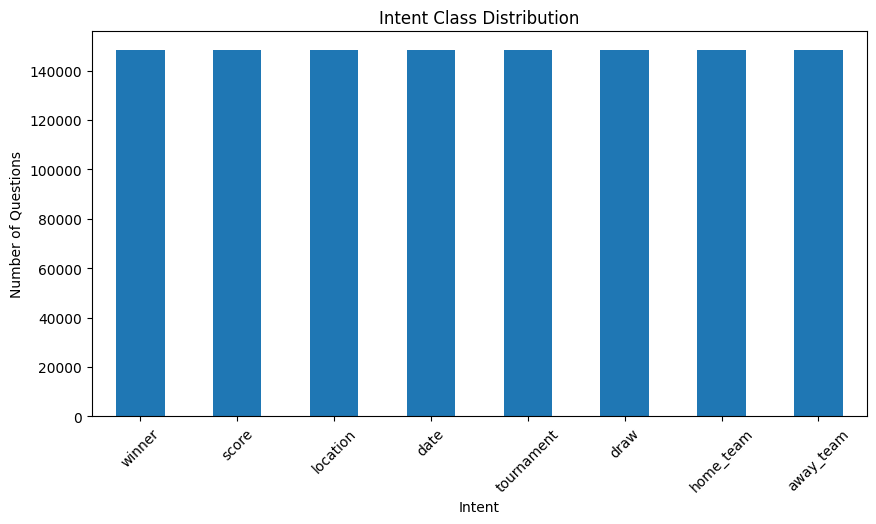

In [18]:
plt.figure(figsize=(10,5))

questions_df["intent"].value_counts().plot(kind="bar")

plt.title("Intent Class Distribution")
plt.xlabel("Intent")
plt.ylabel("Number of Questions")

plt.xticks(rotation=45)

plt.show()

## Check for Duplicate Questions

In [19]:
duplicates = questions_df["question"].duplicated().sum()

print(f"Duplicate Questions: {duplicates}")

Duplicate Questions: 437919


## Display Random Samples

In [20]:
questions_df.sample(10, random_state=42)

,question,intent,home_team,away_team,date,tournament,city,country,home_score,away_score
711367,Which city hosted the match between Bahrain an...,location,Bahrain,Trinidad and Tobago,2005-11-16,FIFA World Cup qualification,Riffa,Bahrain,0.0,1.0
662935,Which city hosted the match between Germany an...,location,Germany,Iceland,2003-10-11,UEFA Euro qualification,Hamburg,Germany,3.0,0.0
325881,When was the match between Ethiopia and Djibou...,date,Ethiopia,Djibouti,1983-03-29,Friendly,Addis Ababa,Ethiopia,4.0,2.0
377407,Which city hosted the match between Thailand a...,location,Thailand,United States,1987-06-16,Korea Cup,Cheongju,South Korea,0.0,1.0
867112,Was the match between Bermuda and Puerto Rico ...,draw,Bermuda,Puerto Rico,2012-09-07,CFU Caribbean Cup qualification,Port-au-Prince,Haiti,1.0,2.0
338414,Which tournament included the match between Ge...,tournament,Germany,Russia,1984-03-28,Friendly,Hanover,Germany,2.0,1.0
849991,Which city hosted the match between Panama and...,location,Panama,Costa Rica,2011-11-11,Friendly,Panama City,Panama,2.0,0.0
346614,Where was the match between Gabon and DR Congo...,location,Gabon,DR Congo,1984-11-25,African Cup of Nations qualification,Libreville,Gabon,1.0,1.0
612013,What competition featured Taiwan against Jorda...,tournament,Taiwan,Jordan,2001-04-25,FIFA World Cup qualification,Tashkent,Uzbekistan,0.0,2.0
760353,When was the match between Trinidad and Tobago...,date,Trinidad and Tobago,Guadeloupe,2008-02-06,Friendly,Port of Spain,Trinidad and Tobago,0.0,0.0


# Section 7.2 Data Preprocessing

## Create a Copy of the Question Column

In [21]:
questions_df["clean_question"] = questions_df["question"]

questions_df[["question", "clean_question"]].head()

,question,clean_question
0,Who won the match between Scotland and England?,Who won the match between Scotland and England?
1,Who won the match between Scotland and England...,Who won the match between Scotland and England...
2,Which team defeated Scotland on 1872-11-30?,Which team defeated Scotland on 1872-11-30?
3,What was the score between Scotland and England?,What was the score between Scotland and England?
4,What was the final score between Scotland and ...,What was the final score between Scotland and ...


## Convert Text to Lowercase

In [22]:
questions_df["clean_question"] = questions_df["clean_question"].str.lower()

questions_df[["question", "clean_question"]].head()

,question,clean_question
0,Who won the match between Scotland and England?,who won the match between scotland and england?
1,Who won the match between Scotland and England...,who won the match between scotland and england...
2,Which team defeated Scotland on 1872-11-30?,which team defeated scotland on 1872-11-30?
3,What was the score between Scotland and England?,what was the score between scotland and england?
4,What was the final score between Scotland and ...,what was the final score between scotland and ...


## Normalize Dates and Remove Punctuation

In [23]:
import re

# Replace dates (YYYY-MM-DD) with the token DATE
questions_df["clean_question"] = questions_df["clean_question"].str.replace(
    r"\d{4}-\d{2}-\d{2}",
    " DATE ",
    regex=True
)

# Remove punctuation
questions_df["clean_question"] = questions_df["clean_question"].str.replace(
    r"[^\w\s]",
    "",
    regex=True
)

questions_df[["question", "clean_question"]].head()

,question,clean_question
0,Who won the match between Scotland and England?,who won the match between scotland and england
1,Who won the match between Scotland and England...,who won the match between scotland and england...
2,Which team defeated Scotland on 1872-11-30?,which team defeated scotland on DATE
3,What was the score between Scotland and England?,what was the score between scotland and england
4,What was the final score between Scotland and ...,what was the final score between scotland and ...


## Tokenization

In [24]:
questions_df["tokens"] = questions_df["clean_question"].apply(word_tokenize)

questions_df[["clean_question", "tokens"]].head()

,clean_question,tokens
0,who won the match between scotland and england,"[who, won, the, match, between, scotland, and,..."
1,who won the match between scotland and england...,"[who, won, the, match, between, scotland, and,..."
2,which team defeated scotland on DATE,"[which, team, defeated, scotland, on, DATE]"
3,what was the score between scotland and england,"[what, was, the, score, between, scotland, and..."
4,what was the final score between scotland and ...,"[what, was, the, final, score, between, scotla..."


## Remove Stop Words

In [25]:
stop_words = set(stopwords.words("english"))

# Keep question words because they help identify the intent
question_words_to_keep = {
    "who",
    "what",
    "when",
    "where",
    "which"
}

# Remove the important question words from the stopword list
stop_words = stop_words - question_words_to_keep

# Remove the remaining stopwords
questions_df["tokens"] = questions_df["tokens"].apply(
    lambda words: [
        word for word in words
        if word not in stop_words
    ]
)

questions_df[["clean_question", "tokens"]].head()

,clean_question,tokens
0,who won the match between scotland and england,"[who, match, scotland, england]"
1,who won the match between scotland and england...,"[who, match, scotland, england, DATE]"
2,which team defeated scotland on DATE,"[which, team, defeated, scotland, DATE]"
3,what was the score between scotland and england,"[what, score, scotland, england]"
4,what was the final score between scotland and ...,"[what, final, score, scotland, england, DATE]"


## Lemmatization

In [26]:
lemmatizer = WordNetLemmatizer()

questions_df["tokens"] = questions_df["tokens"].apply(
    lambda words: [
        lemmatizer.lemmatize(word)
        for word in words
    ]
)

questions_df[["clean_question", "tokens"]].head()

,clean_question,tokens
0,who won the match between scotland and england,"[who, match, scotland, england]"
1,who won the match between scotland and england...,"[who, match, scotland, england, DATE]"
2,which team defeated scotland on DATE,"[which, team, defeated, scotland, DATE]"
3,what was the score between scotland and england,"[what, score, scotland, england]"
4,what was the final score between scotland and ...,"[what, final, score, scotland, england, DATE]"


## Convert Tokens Back to Text

In [27]:
questions_df["clean_question"] = questions_df["tokens"].apply(
    lambda words: " ".join(words)
)

questions_df[["question", "clean_question"]].head()

,question,clean_question
0,Who won the match between Scotland and England?,who match scotland england
1,Who won the match between Scotland and England...,who match scotland england DATE
2,Which team defeated Scotland on 1872-11-30?,which team defeated scotland DATE
3,What was the score between Scotland and England?,what score scotland england
4,What was the final score between Scotland and ...,what final score scotland england DATE


## Compare Original and Cleaned Questions

In [28]:
questions_df[
    ["question", "clean_question", "intent"]
].sample(10, random_state=42)

,question,clean_question,intent
711367,Which city hosted the match between Bahrain an...,which city hosted match bahrain trinidad tobag...,location
662935,Which city hosted the match between Germany an...,which city hosted match germany iceland DATE,location
325881,When was the match between Ethiopia and Djibou...,when match ethiopia djibouti played,date
377407,Which city hosted the match between Thailand a...,which city hosted match thailand united state ...,location
867112,Was the match between Bermuda and Puerto Rico ...,match bermuda puerto rico DATE draw,draw
338414,Which tournament included the match between Ge...,which tournament included match germany russia...,tournament
849991,Which city hosted the match between Panama and...,which city hosted match panama costa rica DATE,location
346614,Where was the match between Gabon and DR Congo...,where match gabon dr congo played,location
612013,What competition featured Taiwan against Jorda...,what competition featured taiwan jordan DATE,tournament
760353,When was the match between Trinidad and Tobago...,when match trinidad tobago guadeloupe played,date


## Installing the WordCloud

In [29]:
!pip install wordcloud

# 7.3 Exploratory Data Analysis (EDA)

## Cell 29 – EDA Overview

In [30]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"Total Samples       : {len(questions_df):,}")
print(f"Number of Columns   : {questions_df.shape[1]}")
print(f"Unique Intents      : {questions_df['intent'].nunique()}")
print(f"Unique Questions    : {questions_df['question'].nunique()}")
print(f"Unique Clean Questions : {questions_df['clean_question'].nunique():,}")

print("\nColumns")
print("-" * 30)

for column in questions_df.columns:
    print(column)

DATASET OVERVIEW
Total Samples       : 1,187,448
Number of Columns   : 12
Unique Intents      : 8
Unique Questions    : 749529
Unique Clean Questions : 258,461

Columns
------------------------------
question
intent
home_team
away_team
date
tournament
city
country
home_score
away_score
clean_question
tokens


## Cell 30 – Missing Values

In [31]:
missing = questions_df.isnull().sum()

missing_df = missing.reset_index()

missing_df.columns = ["Column", "Missing Values"]

missing_df["Percentage"] = (
    missing_df["Missing Values"] /
    len(questions_df)
) * 100

missing_df

,Column,Missing Values,Percentage
0,question,0,0.00000
1,intent,0,0.00000
2,home_team,0,0.00000
3,away_team,0,0.00000
4,date,0,0.00000
5,tournament,0,0.00000
6,city,0,0.00000
7,country,0,0.00000
8,home_score,1056,0.08893
9,away_score,1056,0.08893


## Cell 31 – Duplicate Analysis

In [32]:
print("=" * 50)
print("DUPLICATE ANALYSIS")
print("=" * 50)

duplicate_questions = (
    len(questions_df)
    -
    questions_df["question"].nunique()
)

duplicate_clean = (
    len(questions_df)
    -
    questions_df["clean_question"].nunique()
)

print(f"Duplicate Original Questions : {duplicate_questions:,}")

print(f"Duplicate Clean Questions    : {duplicate_clean:,}")

print()

print(
    f"Original Duplicate Rate : "
    f"{duplicate_questions / len(questions_df) * 100:.2f}%"
)

print(
    f"Clean Duplicate Rate    : "
    f"{duplicate_clean / len(questions_df) * 100:.2f}%"
)

DUPLICATE ANALYSIS
Duplicate Original Questions : 437,919
Duplicate Clean Questions    : 928,987

Original Duplicate Rate : 36.88%
Clean Duplicate Rate    : 78.23%


The high duplicate percentage is expected because multiple question templates generate similar cleaned questions from the same football match records.

## Cell 32 – Intent Distribution

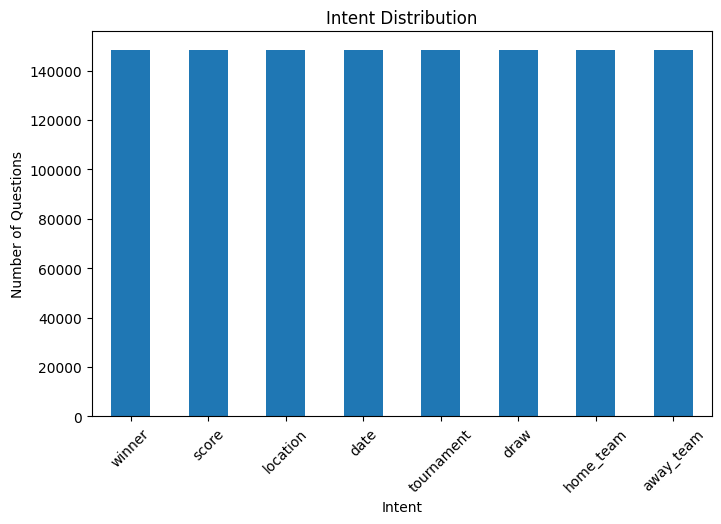

,count
intent,
winner,148431
score,148431
location,148431
date,148431
tournament,148431
draw,148431
home_team,148431
away_team,148431


In [33]:
import matplotlib.pyplot as plt

intent_counts = questions_df["intent"].value_counts()

plt.figure(figsize=(8,5))

intent_counts.plot(kind="bar")

plt.title("Intent Distribution")

plt.xlabel("Intent")

plt.ylabel("Number of Questions")

plt.xticks(rotation=45)

plt.show()

intent_counts

## Cell 33 – Create Unique EDA Dataset

In [34]:
# Use unique cleaned questions for text analysis
eda_df = questions_df.drop_duplicates(
    subset="clean_question"
).copy()

print("Original Samples :", len(questions_df))
print("EDA Samples      :", len(eda_df))

Original Samples : 1187448
EDA Samples      : 258461


## Cell 34 – Question Length Distribution

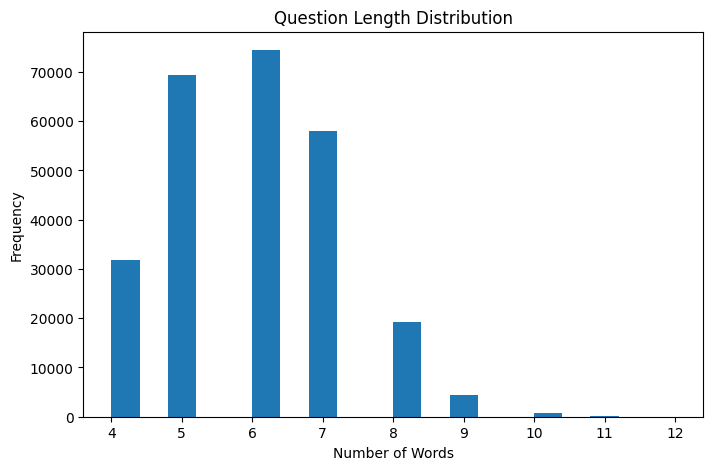

count    258461.000000
mean          5.925865
std           1.225592
min           4.000000
25%           5.000000
50%           6.000000
75%           7.000000
max          12.000000
Name: question_length, dtype: float64


In [35]:
eda_df["question_length"] = eda_df["clean_question"].apply(
    lambda x: len(x.split())
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    eda_df["question_length"],
    bins=20
)

plt.title("Question Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

print(eda_df["question_length"].describe())

## Cell 35 – Top 30 Most Frequent Words

In [36]:
from collections import Counter

all_words = []

for tokens in eda_df["tokens"]:
    all_words.extend(tokens)

word_counts = Counter(all_words)

top_words = word_counts.most_common(30)

import pandas as pd

top_words_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

top_words_df

,Word,Frequency
0,match,172088
1,DATE,135541
2,who,73752
3,what,49168
4,which,37205
5,team,37205
6,played,36878
7,draw,36876
8,score,24584
9,where,24584


The placeholder DATE appears frequently because all calendar dates were normalized into a single token to reduce vocabulary size while preserving temporal information.

## Cell 36 – Word Frequency Visualization

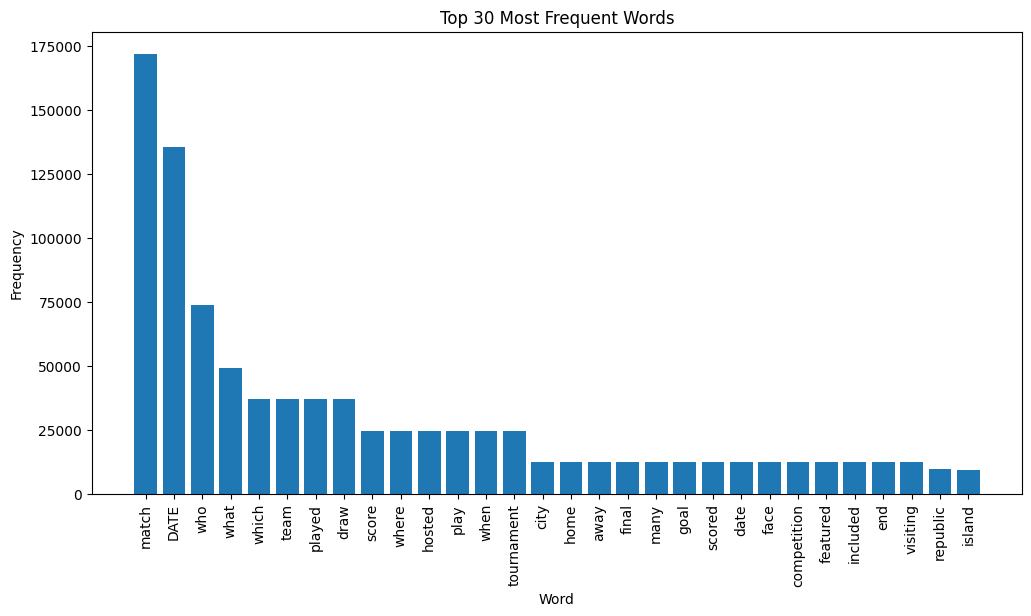

In [37]:
plt.figure(figsize=(12,6))

plt.bar(
    top_words_df["Word"],
    top_words_df["Frequency"]
)

plt.xticks(rotation=90)

plt.title("Top 30 Most Frequent Words")

plt.xlabel("Word")

plt.ylabel("Frequency")

plt.show()

## Cell 37 – Word Cloud

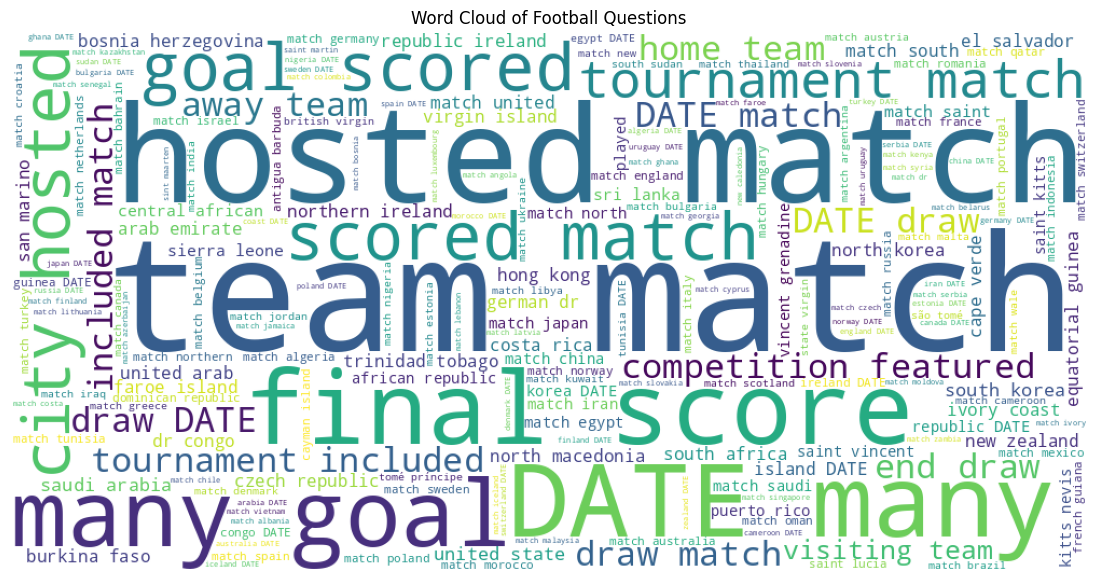

In [38]:
from wordcloud import WordCloud

text = " ".join(eda_df["clean_question"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Football Questions")

plt.show()

## Cell 38 – Vocabulary Statistics

In [39]:
vocabulary = set()

for tokens in eda_df["tokens"]:
    vocabulary.update(tokens)

print("=" * 50)
print("VOCABULARY STATISTICS")
print("=" * 50)

print(f"EDA Samples       : {len(eda_df):,}")
print(f"Vocabulary Size   : {len(vocabulary):,}")

average_length = eda_df["question_length"].mean()

print(f"Average Length    : {average_length:.2f} words")

VOCABULARY STATISTICS
EDA Samples       : 258,461
Vocabulary Size   : 403
Average Length    : 5.93 words


## Cell 39 – EDA Insights

In [40]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print(f"Total Questions           : {len(questions_df):,}")
print(f"Unique Questions          : {questions_df['question'].nunique():,}")
print(f"Unique Clean Questions    : {eda_df['clean_question'].nunique():,}")
print(f"Number of Intents         : {questions_df['intent'].nunique()}")
print(f"Vocabulary Size           : {len(vocabulary):,}")
print(f"Average Question Length   : {average_length:.2f} words")

print("\nKey Insights")
print("-" * 40)
print("• The dataset contains 8 balanced intent classes.")
print("• Question generation produced many duplicate patterns, which is expected because multiple templates were generated from football matches.")
print("• EDA was performed using unique cleaned questions to avoid duplicate bias.")
print("• Most questions contain between 5 and 7 words after preprocessing.")
print("• The vocabulary contains only 403 unique words, reflecting the controlled football-related language.")
print("• The DATE token appears frequently because all dates were normalized during preprocessing.")
print("• The dataset is well suited for TF-IDF feature extraction and intent classification.")

EDA SUMMARY
Total Questions           : 1,187,448
Unique Questions          : 749,529
Unique Clean Questions    : 258,461
Number of Intents         : 8
Vocabulary Size           : 403
Average Question Length   : 5.93 words

Key Insights
----------------------------------------
• The dataset contains 8 balanced intent classes.
• Question generation produced many duplicate patterns, which is expected because multiple templates were generated from football matches.
• EDA was performed using unique cleaned questions to avoid duplicate bias.
• Most questions contain between 5 and 7 words after preprocessing.
• The vocabulary contains only 403 unique words, reflecting the controlled football-related language.
• The DATE token appears frequently because all dates were normalized during preprocessing.
• The dataset is well suited for TF-IDF feature extraction and intent classification.


# Section 7.4 – Feature Engineering / Representation

## Cell 40 – Label Encoding

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

questions_df["intent_encoded"] = label_encoder.fit_transform(
    questions_df["intent"]
)

print("Intent Mapping")
print("-" * 30)

for label, code in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{label:<15} → {code}")

Intent Mapping
------------------------------
away_team       → 0
date            → 1
draw            → 2
home_team       → 3
location        → 4
score           → 5
tournament      → 6
winner          → 7


## Cell 41 – Create Leakage-Free Dataset

In [42]:
ml_df = questions_df.drop_duplicates(
    subset="clean_question"
).copy()

print("Original Samples :", len(questions_df))
print("ML Samples       :", len(ml_df))

print("\nIntent Distribution")

print(ml_df["intent"].value_counts())

Original Samples : 1187448
ML Samples       : 258461

Intent Distribution
intent
score         36876
location      36876
date          36876
tournament    36876
draw          36876
winner        24911
home_team     24585
away_team     24585
Name: count, dtype: int64


## Cell 42 – Leakage-Free Train/Test Split

In [43]:
from sklearn.model_selection import train_test_split

X_text = ml_df["clean_question"]

y = ml_df["intent_encoded"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train_text))
print("Testing Samples  :", len(X_test_text))

Training Samples : 206768
Testing Samples  : 51693


## Cell 43 – Verify No Leakage

In [44]:
train_questions = set(X_train_text)

test_questions = set(X_test_text)

overlap = train_questions.intersection(test_questions)

print("Overlapping Questions :", len(overlap))

if len(overlap) == 0:
    print("✓ No train/test overlap detected.")
else:
    print("⚠ Overlap detected!")

Overlapping Questions : 0
✓ No train/test overlap detected.


## Cell 44 – TF-IDF Vectorization

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_train = tfidf_vectorizer.fit_transform(
    X_train_text
)

X_test = tfidf_vectorizer.transform(
    X_test_text
)

print("Training Matrix :", X_train.shape)
print("Testing Matrix  :", X_test.shape)

Training Matrix : (206768, 402)
Testing Matrix  : (51693, 402)


## Cell 45 – TF-IDF Summary

In [46]:
print("=" * 50)
print("TF-IDF FEATURE SUMMARY")
print("=" * 50)

print(f"Training Samples : {X_train.shape[0]:,}")
print(f"Testing Samples  : {X_test.shape[0]:,}")
print(f"Number of Features : {X_train.shape[1]:,}")

TF-IDF FEATURE SUMMARY
Training Samples : 206,768
Testing Samples  : 51,693
Number of Features : 402


## Cell 46 – Inspect Vocabulary

In [47]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("First 40 TF-IDF Features:\n")

print(feature_names[:40])

First 40 TF-IDF Features:

['abkhazia' 'afghanistan' 'africa' 'african' 'albania' 'alderney'
 'algeria' 'ambazonia' 'american' 'andalusia' 'andorra' 'angola'
 'anguilla' 'antigua' 'arab' 'arabia' 'aramean' 'argentina' 'armenia'
 'artsakh' 'aruba' 'asturias' 'australia' 'austria' 'away' 'aymara'
 'azerbaijan' 'bahamas' 'bahrain' 'bangladesh' 'barawa' 'barbados'
 'barbuda' 'barthélemy' 'basque' 'belarus' 'belgium' 'belize' 'benin'
 'bermuda']


## Cell 47 – Feature Engineering Summary

In [48]:
print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print(f"Original Dataset Size      : {len(questions_df):,}")
print(f"ML Dataset Size            : {len(ml_df):,}")
print(f"Training Samples           : {len(X_train_text):,}")
print(f"Testing Samples            : {len(X_test_text):,}")
print(f"TF-IDF Features            : {X_train.shape[1]:,}")

print("\nFeature Representation")
print("-" * 40)
print("• Labels encoded using LabelEncoder.")
print("• Duplicate clean questions removed for ML.")
print("• Train/Test split performed before vectorization.")
print("• TF-IDF fitted only on training data.")
print("• Test data transformed using the trained TF-IDF vocabulary.")
print("• No train/test data leakage detected.")

FEATURE ENGINEERING SUMMARY
Original Dataset Size      : 1,187,448
ML Dataset Size            : 258,461
Training Samples           : 206,768
Testing Samples            : 51,693
TF-IDF Features            : 402

Feature Representation
----------------------------------------
• Labels encoded using LabelEncoder.
• Duplicate clean questions removed for ML.
• Train/Test split performed before vectorization.
• TF-IDF fitted only on training data.
• Test data transformed using the trained TF-IDF vocabulary.
• No train/test data leakage detected.
